In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import nltk
import re
import string
from nltk.tokenize import RegexpTokenizer
import matplotlib.pyplot as plt
from os import path
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [1]:
# !pip install chart_studio
# !pip install scattertext
# !python -m spacy download en_core_web_md

In [ ]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (10.0, 6.0)
import plotly.graph_objs as go
from plotly.offline import iplot
import cufflinks
pd.options.display.max_columns = 30
from IPython.core.interactiveshell import InteractiveShell
import plotly.figure_factory as ff
InteractiveShell.ast_node_interactivity = 'all'

cufflinks.go_offline()
cufflinks.set_config_file(world_readable=True, theme='pearl')
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.manifold import TSNE
from bokeh.plotting import figure, output_file, show
from bokeh.models import Label
from bokeh.io import output_notebook
output_notebook()
from collections import Counter
import scattertext as st
import spacy
from pprint import pprint
import en_core_web_sm
nlp = spacy.load('en_core_web_md')
import chart_studio


In [ ]:
df1 = pd.read_csv('data1.csv')
df2 = pd.read_csv('data2.csv')
df3 = pd.read_csv('data3.csv')
df4 = pd.read_csv('data4.csv')
df5 = pd.read_csv('data5.csv')
df6 = pd.read_csv('data6.csv')
df7 = pd.read_csv('data7.csv')
df8 = pd.read_csv('data8.csv')
df9 = pd.read_csv('data9.csv')
df10 = pd.read_csv('data10.csv')
df11 = pd.read_csv('data11.csv')
df12 = pd.read_csv('data12.csv')
df13 = pd.read_csv('data13.csv')
df14 = pd.read_csv('data14.csv')
df15 = pd.read_csv('data15.csv')
df16 = pd.read_csv('data16.csv')
df17 = pd.read_csv('data17.csv')

In [ ]:
df = pd.concat([df1,df2,df3,df4,df5,df6,df7,df8,df9,df10,df11,df12,df13,df14,df15,df16,df17], axis=0)

In [ ]:
df.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
df.describe()

,0,1467810369
count,1.599999e+06,1.599999e+06
mean,2.000001e+00,1.998818e+09
std,2.000001e+00,1.935757e+08
min,0.000000e+00,1.467811e+09
25%,0.000000e+00,1.956916e+09
50%,4.000000e+00,2.002102e+09
75%,4.000000e+00,2.177059e+09
max,4.000000e+00,2.329206e+09


#1. Cleaning Data

##1.1. Adding Column Names

In [ ]:
df.columns = ['Class', 'Id', 'Date', 'Flag', 'User', 'Tweet'];
df.head()

,Class,Id,Date,Flag,User,Tweet
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


##1.2. Checking for Nulls

In [ ]:
np.sum(df.isnull().any(axis = 1))

0

##1.3. Conversion of Date to Python Datetime Format

In [ ]:
df.Date = pd.to_datetime(df.Date, format = '%a %b %d %X PDT %Y')
df

,Class,Id,Date,Flag,User,Tweet
0,0,1467810672,2009-04-06 22:19:49,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,2009-04-06 22:19:53,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,2009-04-06 22:19:57,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,2009-04-06 22:19:57,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,2009-04-06 22:20:00,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
...,...,...,...,...,...,...
10,4,2193601966,2009-06-16 08:40:49,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
11,4,2193601969,2009-06-16 08:40:49,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
12,4,2193601991,2009-06-16 08:40:49,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
13,4,2193602064,2009-06-16 08:40:49,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


##1.4. Dropping Surplus Columns

In [ ]:
df['Flag']. value_counts()

NO_QUERY    1599999
Name: Flag, dtype: int64

In [ ]:
df.drop('Flag', axis = 1, inplace = True)

In [ ]:
df.head()

,Class,Id,Date,User,Tweet
0,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,2009-04-06 22:19:53,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,2009-04-06 22:20:00,joy_wolf,@Kwesidei not the whole crew


##1.5 Removing Duplicate Rows

In [ ]:
df.Id.value_counts()

1753678185    2
1678693526    2
1835870889    2
2190104868    2
1984377787    2
             ..
2056931811    1
2212131300    1
2188589814    1
1983537638    1
1964587131    1
Name: Id, Length: 1598314, dtype: int64

In [ ]:
df[df.Id == 1753678185]

,Class,Id,Date,User,Tweet
84765,0,1753678185,2009-05-10 02:51:55,BoydyxO,sunnn finnalllyyy!! aint slept :| need some s...
18547,4,1753678185,2009-05-10 02:51:55,BoydyxO,sunnn finnalllyyy!! aint slept :| need some s...


In [ ]:
df = df.drop_duplicates(subset = 'Id')

In [ ]:
df.Id.value_counts()

1975519231    1
1982249346    1
1836114731    1
1753348458    1
1694626155    1
             ..
2175720305    1
2048719540    1
1985216237    1
1880025975    1
1964587131    1
Name: Id, Length: 1598314, dtype: int64

In [ ]:
df.Class.value_counts()

0    799999
4    798315
Name: Class, dtype: int64

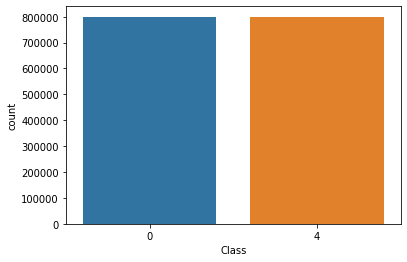

In [ ]:
sns.countplot(x='Class', data=df)

##1.6. Renaming the Classes to 0 and 1

In [ ]:
df['Class'] = df['Class'].replace(4,1)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [ ]:
df

,Class,Id,Date,User,Tweet
0,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,2009-04-06 22:19:53,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,2009-04-06 22:20:00,joy_wolf,@Kwesidei not the whole crew
...,...,...,...,...,...
10,1,2193601966,2009-06-16 08:40:49,AmandaMarie1028,Just woke up. Having no school is the best fee...
11,1,2193601969,2009-06-16 08:40:49,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
12,1,2193601991,2009-06-16 08:40:49,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
13,1,2193602064,2009-06-16 08:40:49,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


##1.7. Converting Tweets to Lower Case

In [ ]:
df.Tweet = df.Tweet.str.lower()

/usr/local/lib/python3.7/dist-packages/pandas/core/generic.py:5170: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


In [ ]:
df

,Class,Id,Date,User,Tweet
0,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his facebook by ...
1,0,1467810917,2009-04-06 22:19:53,mattycus,@kenichan i dived many times for the ball. man...
2,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,2009-04-06 22:20:00,joy_wolf,@kwesidei not the whole crew
...,...,...,...,...,...
10,1,2193601966,2009-06-16 08:40:49,AmandaMarie1028,just woke up. having no school is the best fee...
11,1,2193601969,2009-06-16 08:40:49,TheWDBoards,thewdb.com - very cool to hear old walt interv...
12,1,2193601991,2009-06-16 08:40:49,bpbabe,are you ready for your mojo makeover? ask me f...
13,1,2193602064,2009-06-16 08:40:49,tinydiamondz,happy 38th birthday to my boo of alll time!!! ...


##1.8. Removing Stop Words and Letters Repeating More than 2 Times

In [ ]:
def cleaning_repeating_char(text):
    return re.sub(r'([a-z])\1+', r'\1\1', text)
df['Tweet'] = df['Tweet'].apply(lambda x: cleaning_repeating_char(x))
df

,Class,Id,Date,User,Tweet,TweetMinusStopWords,TweetTokens,TweetTokensStemmed
0,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his facebook by ...,upset cant update facebook texting it might cr...,"[upset, cant, update, facebook, texting, it, m...","[upset, cant, updat, facebook, text, it, might..."
1,0,1467810917,2009-04-06 22:19:53,mattycus,@kenichan i dived many times for the ball. man...,dived many times ball managed save rest go bo...,"[dived, many, time, ball, managed, save, rest,...","[dive, mani, time, ball, manag, save, rest, go..."
2,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire,whole body feels itchy like fire,"[whole, body, feel, itchy, like, fire]","[whole, bodi, feel, itchi, like, fire]"
3,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all....",no behaving all im mad here cant see there,"[no, behaving, all, im, mad, here, cant, see, ...","[no, behav, all, im, mad, here, cant, see, there]"
4,0,1467811372,2009-04-06 22:20:00,joy_wolf,@kwesidei not the whole crew,whole crew,"[whole, crew]","[whole, crew]"
...,...,...,...,...,...,...,...,...
10,1,2193601966,2009-06-16 08:40:49,AmandaMarie1028,just woke up. having no school is the best fee...,woke up school best feeling ever,"[woke, up, school, best, feeling, ever]","[woke, up, school, best, feel, ever]"
11,1,2193601969,2009-06-16 08:40:49,TheWDBoards,thewdb.com - very cool to hear old walt interv...,cool hear old walt interviews ♫,"[cool, hear, old, walt, interview, ♫]","[cool, hear, old, walt, interview, ♫]"
12,1,2193601991,2009-06-16 08:40:49,bpbabe,are you ready for your mojo makeover? ask me f...,ready mojo makeover ask details,"[ready, mojo, makeover, ask, detail]","[readi, mojo, makeov, ask, detail]"
13,1,2193602064,2009-06-16 08:40:49,tinydiamondz,happy 38th birthday to my boo of all time!!! t...,happy th birthday boo time tupac amaru shakur,"[happy, th, birthday, boo, time, tupac, amaru,...","[happi, th, birthday, boo, time, tupac, amaru,..."


In [ ]:
nltk.download('stopwords')

negations_dic = {"isn't":"is not", "aren't":"are not", "wasn't":"was not", "weren't":"were not",
                "haven't":"have not","hasn't":"has not","hadn't":"had not","won't":"will not",
                "wouldn't":"would not", "don't":"do not", "doesn't":"does not","didn't":"did not",
                "can't":"can not","couldn't":"could not","shouldn't":"should not","mightn't":"might not",
                "mustn't":"must not", "i'm":"i am"}
neg_pattern = re.compile(r'\b(' + '|'.join(negations_dic.keys()) + r')\b')


stopwords = nltk.corpus.stopwords.words('english')
stopwords.remove('not')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
df['TweetMinusStopWords'] = [neg_pattern.sub(lambda x: negations_dic[x.group()], x) for x in df.Tweet]

df['TweetMinusStopWords'] = df['TweetMinusStopWords'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stopwords)]))

In [ ]:
df

,Class,Id,Date,User,Tweet,TweetMinusStopWords,TweetTokens,TweetTokensStemmed
0,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his facebook by ...,upset not update facebook texting it... might ...,"[upset, cant, update, facebook, texting, it, m...","[upset, cant, updat, facebook, text, it, might..."
1,0,1467810917,2009-04-06 22:19:53,mattycus,@kenichan i dived many times for the ball. man...,@kenichan dived many times ball. managed save ...,"[dived, many, time, ball, managed, save, rest,...","[dive, mani, time, ball, manag, save, rest, go..."
2,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire,whole body feels itchy like fire,"[whole, body, feel, itchy, like, fire]","[whole, bodi, feel, itchi, like, fire]"
3,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all....","@nationwideclass no, not behaving all. mad. he...","[no, behaving, all, im, mad, here, cant, see, ...","[no, behav, all, im, mad, here, cant, see, there]"
4,0,1467811372,2009-04-06 22:20:00,joy_wolf,@kwesidei not the whole crew,@kwesidei not whole crew,"[whole, crew]","[whole, crew]"
...,...,...,...,...,...,...,...,...
10,1,2193601966,2009-06-16 08:40:49,AmandaMarie1028,just woke up. having no school is the best fee...,woke up. school best feeling ever,"[woke, up, school, best, feeling, ever]","[woke, up, school, best, feel, ever]"
11,1,2193601969,2009-06-16 08:40:49,TheWDBoards,thewdb.com - very cool to hear old walt interv...,thewdb.com - cool hear old walt interviews! ♫ ...,"[cool, hear, old, walt, interview, ♫]","[cool, hear, old, walt, interview, ♫]"
12,1,2193601991,2009-06-16 08:40:49,bpbabe,are you ready for your mojo makeover? ask me f...,ready mojo makeover? ask details,"[ready, mojo, makeover, ask, detail]","[readi, mojo, makeov, ask, detail]"
13,1,2193602064,2009-06-16 08:40:49,tinydiamondz,happy 38th birthday to my boo of all time!!! t...,happy 38th birthday boo time!!! tupac amaru sh...,"[happy, th, birthday, boo, time, tupac, amaru,...","[happi, th, birthday, boo, time, tupac, amaru,..."


##1.9. Removing @ and Hashtag Words

In [ ]:
df['TweetMinusStopWords'] = df['TweetMinusStopWords'].apply(lambda x: ' '.join([word for word in x.split() if (re.match('^(?!@+).', word))]))


In [ ]:
df['TweetMinusStopWords'] = df['TweetMinusStopWords'].apply(lambda x: ' '.join([word for word in x.split() if (re.match('^(?!#+).', word))]))


In [ ]:
df

,Class,Id,Date,User,Tweet,TweetMinusStopWords,TweetTokens,TweetTokensStemmed
0,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his facebook by ...,upset not update facebook texting it... might ...,"[upset, cant, update, facebook, texting, it, m...","[upset, cant, updat, facebook, text, it, might..."
1,0,1467810917,2009-04-06 22:19:53,mattycus,@kenichan i dived many times for the ball. man...,dived many times ball. managed save 50% rest g...,"[dived, many, time, ball, managed, save, rest,...","[dive, mani, time, ball, manag, save, rest, go..."
2,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire,whole body feels itchy like fire,"[whole, body, feel, itchy, like, fire]","[whole, bodi, feel, itchi, like, fire]"
3,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all....","no, not behaving all. mad. here? not see there.","[no, behaving, all, im, mad, here, cant, see, ...","[no, behav, all, im, mad, here, cant, see, there]"
4,0,1467811372,2009-04-06 22:20:00,joy_wolf,@kwesidei not the whole crew,not whole crew,"[whole, crew]","[whole, crew]"
...,...,...,...,...,...,...,...,...
10,1,2193601966,2009-06-16 08:40:49,AmandaMarie1028,just woke up. having no school is the best fee...,woke up. school best feeling ever,"[woke, up, school, best, feeling, ever]","[woke, up, school, best, feel, ever]"
11,1,2193601969,2009-06-16 08:40:49,TheWDBoards,thewdb.com - very cool to hear old walt interv...,thewdb.com - cool hear old walt interviews! ♫ ...,"[cool, hear, old, walt, interview, ♫]","[cool, hear, old, walt, interview, ♫]"
12,1,2193601991,2009-06-16 08:40:49,bpbabe,are you ready for your mojo makeover? ask me f...,ready mojo makeover? ask details,"[ready, mojo, makeover, ask, detail]","[readi, mojo, makeov, ask, detail]"
13,1,2193602064,2009-06-16 08:40:49,tinydiamondz,happy 38th birthday to my boo of all time!!! t...,happy 38th birthday boo time!!! tupac amaru sh...,"[happy, th, birthday, boo, time, tupac, amaru,...","[happi, th, birthday, boo, time, tupac, amaru,..."


##1.10 Removing URLs

In [ ]:
df['TweetMinusStopWords'] = df['TweetMinusStopWords'].apply(lambda x: ' '.join([word for word in x.split() if (re.match('^(?!^(http:\/\/www\.|https:\/\/www\.|http:\/\/|https:\/\/)?[a-z0-9]+([\-\.]{1}[a-z0-9]+)*\.[a-z]{2,5}(:[0-9]{1,5})?(\/.*)?$).', word))]))

In [ ]:
df

,Class,Id,Date,User,Tweet,TweetMinusStopWords,TweetTokens,TweetTokensStemmed
0,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his facebook by ...,upset not update facebook texting it... might ...,"[upset, cant, update, facebook, texting, it, m...","[upset, cant, updat, facebook, text, it, might..."
1,0,1467810917,2009-04-06 22:19:53,mattycus,@kenichan i dived many times for the ball. man...,dived many times ball. managed save 50% rest g...,"[dived, many, time, ball, managed, save, rest,...","[dive, mani, time, ball, manag, save, rest, go..."
2,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire,whole body feels itchy like fire,"[whole, body, feel, itchy, like, fire]","[whole, bodi, feel, itchi, like, fire]"
3,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all....","no, not behaving all. mad. here? not see there.","[no, behaving, all, im, mad, here, cant, see, ...","[no, behav, all, im, mad, here, cant, see, there]"
4,0,1467811372,2009-04-06 22:20:00,joy_wolf,@kwesidei not the whole crew,not whole crew,"[whole, crew]","[whole, crew]"
...,...,...,...,...,...,...,...,...
10,1,2193601966,2009-06-16 08:40:49,AmandaMarie1028,just woke up. having no school is the best fee...,woke up. school best feeling ever,"[woke, up, school, best, feeling, ever]","[woke, up, school, best, feel, ever]"
11,1,2193601969,2009-06-16 08:40:49,TheWDBoards,thewdb.com - very cool to hear old walt interv...,- cool hear old walt interviews! ♫,"[cool, hear, old, walt, interview, ♫]","[cool, hear, old, walt, interview, ♫]"
12,1,2193601991,2009-06-16 08:40:49,bpbabe,are you ready for your mojo makeover? ask me f...,ready mojo makeover? ask details,"[ready, mojo, makeover, ask, detail]","[readi, mojo, makeov, ask, detail]"
13,1,2193602064,2009-06-16 08:40:49,tinydiamondz,happy 38th birthday to my boo of all time!!! t...,happy 38th birthday boo time!!! tupac amaru sh...,"[happy, th, birthday, boo, time, tupac, amaru,...","[happi, th, birthday, boo, time, tupac, amaru,..."


##1.11 Removing Numbers

In [ ]:
df['TweetMinusStopWords'] = df['TweetMinusStopWords'].apply(lambda x: re.sub('[0-9]+', '', x))

In [ ]:
df

,Class,Id,Date,User,Tweet,TweetMinusStopWords,TweetTokens,TweetTokensStemmed
0,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his facebook by ...,upset not update facebook texting it... might ...,"[upset, cant, update, facebook, texting, it, m...","[upset, cant, updat, facebook, text, it, might..."
1,0,1467810917,2009-04-06 22:19:53,mattycus,@kenichan i dived many times for the ball. man...,dived many times ball. managed save % rest go ...,"[dived, many, time, ball, managed, save, rest,...","[dive, mani, time, ball, manag, save, rest, go..."
2,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire,whole body feels itchy like fire,"[whole, body, feel, itchy, like, fire]","[whole, bodi, feel, itchi, like, fire]"
3,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all....","no, not behaving all. mad. here? not see there.","[no, behaving, all, im, mad, here, cant, see, ...","[no, behav, all, im, mad, here, cant, see, there]"
4,0,1467811372,2009-04-06 22:20:00,joy_wolf,@kwesidei not the whole crew,not whole crew,"[whole, crew]","[whole, crew]"
...,...,...,...,...,...,...,...,...
10,1,2193601966,2009-06-16 08:40:49,AmandaMarie1028,just woke up. having no school is the best fee...,woke up. school best feeling ever,"[woke, up, school, best, feeling, ever]","[woke, up, school, best, feel, ever]"
11,1,2193601969,2009-06-16 08:40:49,TheWDBoards,thewdb.com - very cool to hear old walt interv...,- cool hear old walt interviews! ♫,"[cool, hear, old, walt, interview, ♫]","[cool, hear, old, walt, interview, ♫]"
12,1,2193601991,2009-06-16 08:40:49,bpbabe,are you ready for your mojo makeover? ask me f...,ready mojo makeover? ask details,"[ready, mojo, makeover, ask, detail]","[readi, mojo, makeov, ask, detail]"
13,1,2193602064,2009-06-16 08:40:49,tinydiamondz,happy 38th birthday to my boo of all time!!! t...,happy th birthday boo time!!! tupac amaru shakur,"[happy, th, birthday, boo, time, tupac, amaru,...","[happi, th, birthday, boo, time, tupac, amaru,..."


##1.12 Removing Punctuations

In [ ]:
english_punctuations = string.punctuation
punctuations_list = english_punctuations
def cleaning_punctuations(text):
    translator = str.maketrans('', '', punctuations_list)
    return text.translate(translator)

df['TweetMinusStopWords'] = df['TweetMinusStopWords'].apply(lambda x: cleaning_punctuations(x))

In [ ]:
df

,Class,Id,Date,User,Tweet,TweetMinusStopWords,TweetTokens,TweetTokensStemmed
0,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his facebook by ...,upset not update facebook texting it might cry...,"[upset, cant, update, facebook, texting, it, m...","[upset, cant, updat, facebook, text, it, might..."
1,0,1467810917,2009-04-06 22:19:53,mattycus,@kenichan i dived many times for the ball. man...,dived many times ball managed save rest go bo...,"[dived, many, time, ball, managed, save, rest,...","[dive, mani, time, ball, manag, save, rest, go..."
2,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire,whole body feels itchy like fire,"[whole, body, feel, itchy, like, fire]","[whole, bodi, feel, itchi, like, fire]"
3,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all....",no not behaving all mad here not see there,"[no, behaving, all, im, mad, here, cant, see, ...","[no, behav, all, im, mad, here, cant, see, there]"
4,0,1467811372,2009-04-06 22:20:00,joy_wolf,@kwesidei not the whole crew,not whole crew,"[whole, crew]","[whole, crew]"
...,...,...,...,...,...,...,...,...
10,1,2193601966,2009-06-16 08:40:49,AmandaMarie1028,just woke up. having no school is the best fee...,woke up school best feeling ever,"[woke, up, school, best, feeling, ever]","[woke, up, school, best, feel, ever]"
11,1,2193601969,2009-06-16 08:40:49,TheWDBoards,thewdb.com - very cool to hear old walt interv...,cool hear old walt interviews ♫,"[cool, hear, old, walt, interview, ♫]","[cool, hear, old, walt, interview, ♫]"
12,1,2193601991,2009-06-16 08:40:49,bpbabe,are you ready for your mojo makeover? ask me f...,ready mojo makeover ask details,"[ready, mojo, makeover, ask, detail]","[readi, mojo, makeov, ask, detail]"
13,1,2193602064,2009-06-16 08:40:49,tinydiamondz,happy 38th birthday to my boo of all time!!! t...,happy th birthday boo time tupac amaru shakur,"[happy, th, birthday, boo, time, tupac, amaru,...","[happi, th, birthday, boo, time, tupac, amaru,..."


#1.13 Splitting String into List of Words

In [ ]:
tokenizer = RegexpTokenizer(r'+')
df['TweetTokens'] = df['TweetMinusStopWords'].apply(lambda x:str.split(x))
df

,Class,Id,Date,User,Tweet,TweetMinusStopWords,TweetTokens,TweetTokensStemmed
0,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his facebook by ...,upset not update facebook texting it might cry...,"[upset, not, update, facebook, texting, it, mi...","[upset, cant, updat, facebook, text, it, might..."
1,0,1467810917,2009-04-06 22:19:53,mattycus,@kenichan i dived many times for the ball. man...,dived many times ball managed save rest go bo...,"[dived, many, times, ball, managed, save, rest...","[dive, mani, time, ball, manag, save, rest, go..."
2,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire,whole body feels itchy like fire,"[whole, body, feels, itchy, like, fire]","[whole, bodi, feel, itchi, like, fire]"
3,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all....",no not behaving all mad here not see there,"[no, not, behaving, all, mad, here, not, see, ...","[no, behav, all, im, mad, here, cant, see, there]"
4,0,1467811372,2009-04-06 22:20:00,joy_wolf,@kwesidei not the whole crew,not whole crew,"[not, whole, crew]","[whole, crew]"
...,...,...,...,...,...,...,...,...
10,1,2193601966,2009-06-16 08:40:49,AmandaMarie1028,just woke up. having no school is the best fee...,woke up school best feeling ever,"[woke, up, school, best, feeling, ever]","[woke, up, school, best, feel, ever]"
11,1,2193601969,2009-06-16 08:40:49,TheWDBoards,thewdb.com - very cool to hear old walt interv...,cool hear old walt interviews ♫,"[cool, hear, old, walt, interviews, ♫]","[cool, hear, old, walt, interview, ♫]"
12,1,2193601991,2009-06-16 08:40:49,bpbabe,are you ready for your mojo makeover? ask me f...,ready mojo makeover ask details,"[ready, mojo, makeover, ask, details]","[readi, mojo, makeov, ask, detail]"
13,1,2193602064,2009-06-16 08:40:49,tinydiamondz,happy 38th birthday to my boo of all time!!! t...,happy th birthday boo time tupac amaru shakur,"[happy, th, birthday, boo, time, tupac, amaru,...","[happi, th, birthday, boo, time, tupac, amaru,..."


##1.14 Getting Root Words (Stemming and Lemmatizing)

In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
st = nltk.PorterStemmer()
lm = nltk.WordNetLemmatizer()
def lem(data):
    text = [lm.lemmatize(word) for word in data]
    return text

df['TweetTokens'] = df['TweetTokens'].apply(lambda x: lem(x))
df

,Class,Id,Date,User,Tweet,TweetMinusStopWords,TweetTokens,TweetTokensStemmed
0,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his facebook by ...,upset not update facebook texting it might cry...,"[upset, not, update, facebook, texting, it, mi...","[upset, cant, updat, facebook, text, it, might..."
1,0,1467810917,2009-04-06 22:19:53,mattycus,@kenichan i dived many times for the ball. man...,dived many times ball managed save rest go bo...,"[dived, many, time, ball, managed, save, rest,...","[dive, mani, time, ball, manag, save, rest, go..."
2,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire,whole body feels itchy like fire,"[whole, body, feel, itchy, like, fire]","[whole, bodi, feel, itchi, like, fire]"
3,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all....",no not behaving all mad here not see there,"[no, not, behaving, all, mad, here, not, see, ...","[no, behav, all, im, mad, here, cant, see, there]"
4,0,1467811372,2009-04-06 22:20:00,joy_wolf,@kwesidei not the whole crew,not whole crew,"[not, whole, crew]","[whole, crew]"
...,...,...,...,...,...,...,...,...
10,1,2193601966,2009-06-16 08:40:49,AmandaMarie1028,just woke up. having no school is the best fee...,woke up school best feeling ever,"[woke, up, school, best, feeling, ever]","[woke, up, school, best, feel, ever]"
11,1,2193601969,2009-06-16 08:40:49,TheWDBoards,thewdb.com - very cool to hear old walt interv...,cool hear old walt interviews ♫,"[cool, hear, old, walt, interview, ♫]","[cool, hear, old, walt, interview, ♫]"
12,1,2193601991,2009-06-16 08:40:49,bpbabe,are you ready for your mojo makeover? ask me f...,ready mojo makeover ask details,"[ready, mojo, makeover, ask, detail]","[readi, mojo, makeov, ask, detail]"
13,1,2193602064,2009-06-16 08:40:49,tinydiamondz,happy 38th birthday to my boo of all time!!! t...,happy th birthday boo time tupac amaru shakur,"[happy, th, birthday, boo, time, tupac, amaru,...","[happi, th, birthday, boo, time, tupac, amaru,..."


In [ ]:
df

,Class,Id,Date,User,Tweet,TweetMinusStopWords,TweetTokens,TweetTokensStemmed
0,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his facebook by ...,upset not update facebook texting it might cry...,"[upset, not, update, facebook, texting, it, mi...","[upset, cant, updat, facebook, text, it, might..."
1,0,1467810917,2009-04-06 22:19:53,mattycus,@kenichan i dived many times for the ball. man...,dived many times ball managed save rest go bo...,"[dived, many, time, ball, managed, save, rest,...","[dive, mani, time, ball, manag, save, rest, go..."
2,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire,whole body feels itchy like fire,"[whole, body, feel, itchy, like, fire]","[whole, bodi, feel, itchi, like, fire]"
3,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all....",no not behaving all mad here not see there,"[no, not, behaving, all, mad, here, not, see, ...","[no, behav, all, im, mad, here, cant, see, there]"
4,0,1467811372,2009-04-06 22:20:00,joy_wolf,@kwesidei not the whole crew,not whole crew,"[not, whole, crew]","[whole, crew]"
...,...,...,...,...,...,...,...,...
10,1,2193601966,2009-06-16 08:40:49,AmandaMarie1028,just woke up. having no school is the best fee...,woke up school best feeling ever,"[woke, up, school, best, feeling, ever]","[woke, up, school, best, feel, ever]"
11,1,2193601969,2009-06-16 08:40:49,TheWDBoards,thewdb.com - very cool to hear old walt interv...,cool hear old walt interviews ♫,"[cool, hear, old, walt, interview, ♫]","[cool, hear, old, walt, interview, ♫]"
12,1,2193601991,2009-06-16 08:40:49,bpbabe,are you ready for your mojo makeover? ask me f...,ready mojo makeover ask details,"[ready, mojo, makeover, ask, detail]","[readi, mojo, makeov, ask, detail]"
13,1,2193602064,2009-06-16 08:40:49,tinydiamondz,happy 38th birthday to my boo of all time!!! t...,happy th birthday boo time tupac amaru shakur,"[happy, th, birthday, boo, time, tupac, amaru,...","[happi, th, birthday, boo, time, tupac, amaru,..."


In [ ]:
def lem(data):
    text = [st.stem(word) for word in data]
    return text

df['TweetTokensStemmed'] = df['TweetTokens'].apply(lambda x: lem(x))
df

,Class,Id,Date,User,Tweet,TweetMinusStopWords,TweetTokens,TweetTokensStemmed
0,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his facebook by ...,upset not update facebook texting it might cry...,"[upset, not, update, facebook, texting, it, mi...","[upset, not, updat, facebook, text, it, might,..."
1,0,1467810917,2009-04-06 22:19:53,mattycus,@kenichan i dived many times for the ball. man...,dived many times ball managed save rest go bo...,"[dived, many, time, ball, managed, save, rest,...","[dive, mani, time, ball, manag, save, rest, go..."
2,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire,whole body feels itchy like fire,"[whole, body, feel, itchy, like, fire]","[whole, bodi, feel, itchi, like, fire]"
3,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all....",no not behaving all mad here not see there,"[no, not, behaving, all, mad, here, not, see, ...","[no, not, behav, all, mad, here, not, see, there]"
4,0,1467811372,2009-04-06 22:20:00,joy_wolf,@kwesidei not the whole crew,not whole crew,"[not, whole, crew]","[not, whole, crew]"
...,...,...,...,...,...,...,...,...
10,1,2193601966,2009-06-16 08:40:49,AmandaMarie1028,just woke up. having no school is the best fee...,woke up school best feeling ever,"[woke, up, school, best, feeling, ever]","[woke, up, school, best, feel, ever]"
11,1,2193601969,2009-06-16 08:40:49,TheWDBoards,thewdb.com - very cool to hear old walt interv...,cool hear old walt interviews ♫,"[cool, hear, old, walt, interview, ♫]","[cool, hear, old, walt, interview, ♫]"
12,1,2193601991,2009-06-16 08:40:49,bpbabe,are you ready for your mojo makeover? ask me f...,ready mojo makeover ask details,"[ready, mojo, makeover, ask, detail]","[readi, mojo, makeov, ask, detail]"
13,1,2193602064,2009-06-16 08:40:49,tinydiamondz,happy 38th birthday to my boo of all time!!! t...,happy th birthday boo time tupac amaru shakur,"[happy, th, birthday, boo, time, tupac, amaru,...","[happi, th, birthday, boo, time, tupac, amaru,..."


#2. Preliminary Analysis

##2.1. Most Common Words

<Figure size 1440x1440 with 0 Axes>

Text(0.5, 1.0, 'Most Common Words Overall')

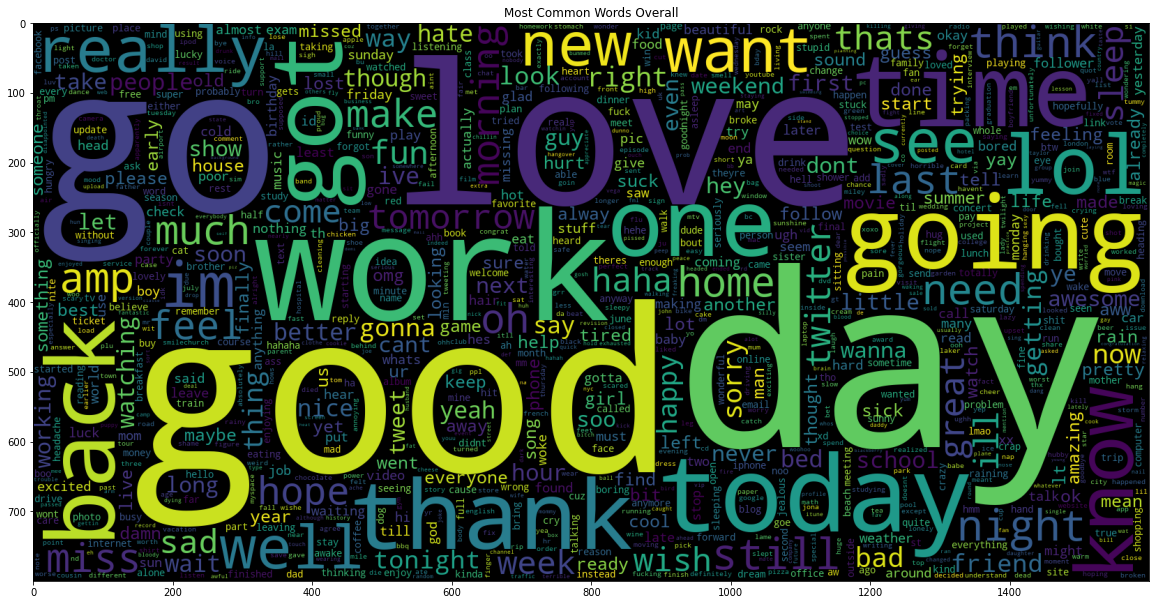

In [ ]:
data_neg = df['TweetMinusStopWords']
plt.figure(figsize = (20,20))
plt.title('Most Common Words Overall')
wc = WordCloud(max_words = 1000 , width = 1600 , height = 800, collocations=False).generate(" ".join(data_neg))
plt.imshow(wc)

<Figure size 1440x1440 with 0 Axes>

Text(0.5, 1.0, 'Most Common Words in Class 0')

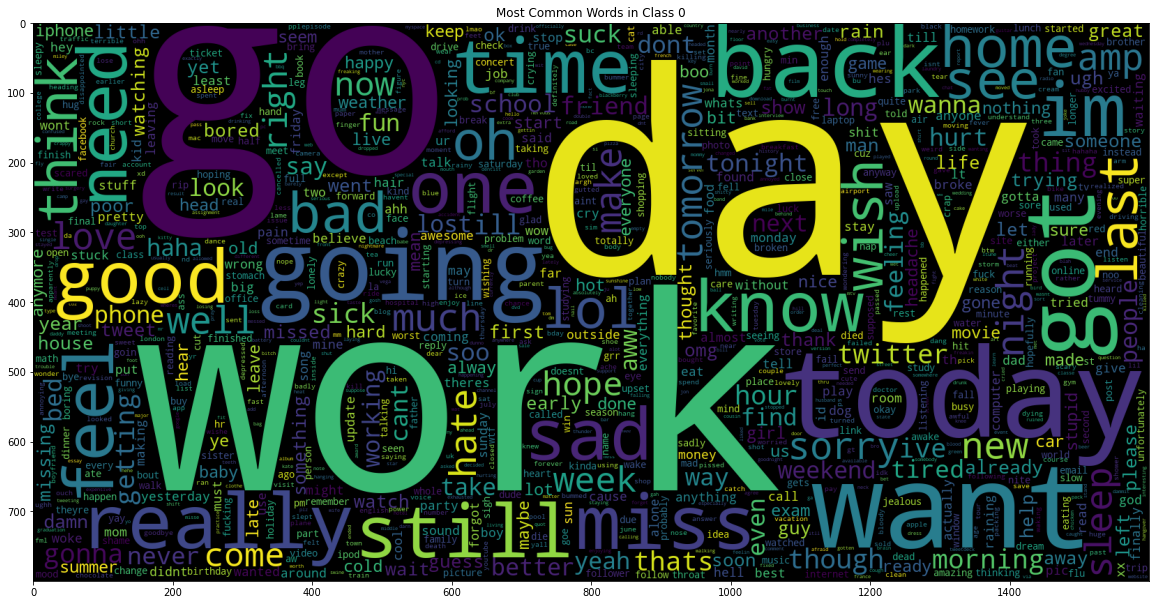

In [ ]:
data_neg = df['TweetMinusStopWords'][df['Class'] == 0]
plt.figure(figsize = (20,20))
plt.title('Most Common Words in Class 0')
wc = WordCloud(max_words = 1000 , width = 1600 , height = 800, collocations=False).generate(" ".join(data_neg))
plt.imshow(wc)

<Figure size 1440x1440 with 0 Axes>

Text(0.5, 1.0, 'Most Common Words in Class 4')

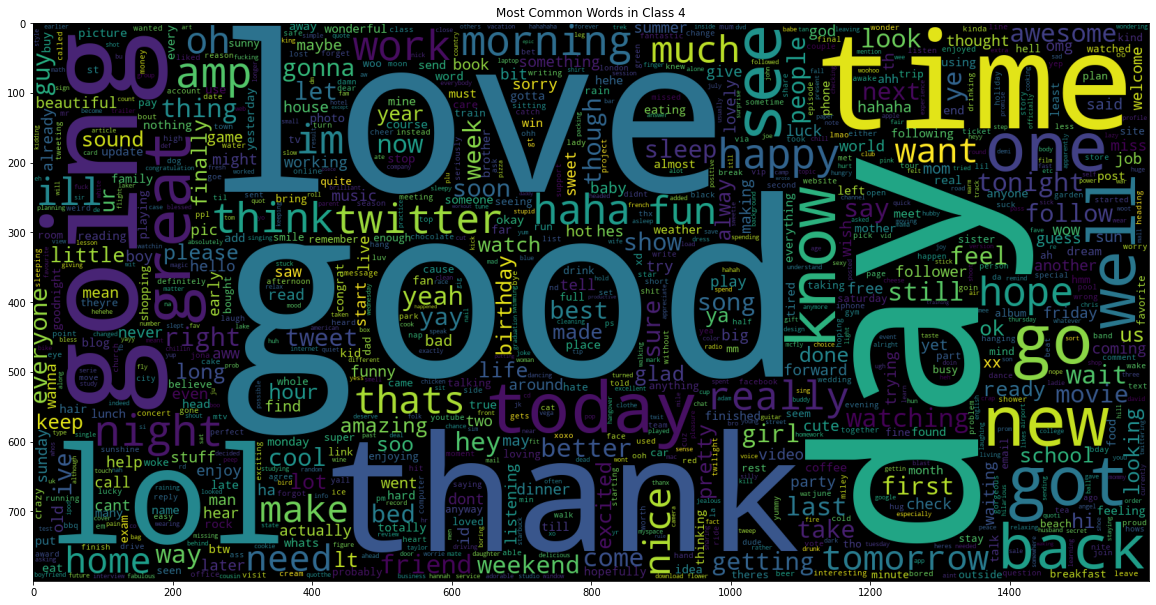

In [ ]:
data_neg = df['TweetMinusStopWords'][df['Class'] == 1]
plt.figure(figsize = (20,20))
plt.title('Most Common Words in Class 4')
wc = WordCloud(max_words = 1000 , width = 1600 , height = 800, collocations=False).generate(" ".join(data_neg))
plt.imshow(wc)

##2.2. Most Common Bigrams

In [ ]:
def configure_plotly_browser_state():
  import IPython
  display(IPython.core.display.HTML('''
        <script src="/static/components/requirejs/require.js"></script>
        <script>
          requirejs.config({
            paths: {
              base: '/static/base',
              plotly: 'https://cdn.plot.ly/plotly-latest.min.js?noext',
            },
          });
        </script>
        '''))

In [ ]:
def get_top_n_bigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]
common_words = get_top_n_bigram(df['TweetMinusStopWords'], 20)
df3 = pd.DataFrame(common_words, columns = ['Tweet' , 'Count'])


In [ ]:
configure_plotly_browser_state()
df3.groupby('Tweet').sum()['Count'].sort_values(ascending=False).iplot(kind='bar', yTitle='Count', linecolor='black', title='Top 20 Bigrams Overall')

In [ ]:
common_words = get_top_n_bigram(df['TweetMinusStopWords'][df.Class == 0], 20)
df1 = pd.DataFrame(common_words, columns = ['Tweet' , 'Count'])
common_words = get_top_n_bigram(df['TweetMinusStopWords'][df.Class == 1], 20)
df2 = pd.DataFrame(common_words, columns = ['Tweet' , 'Count'])

In [ ]:
configure_plotly_browser_state()
df1.groupby('Tweet').sum()['Count'].sort_values(ascending=False).iplot(kind='bar', yTitle='Count', linecolor='black', title='Top 20 Bigrams for Class 0')

In [ ]:
configure_plotly_browser_state()
df2.groupby('Tweet').sum()['Count'].sort_values(ascending=False).iplot(kind='bar', yTitle='Count', linecolor='black', title='Top 20 Bigrams for Class 4')

##2.3. Most Common Trigrams

In [ ]:
def get_top_n_trigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]
common_words = get_top_n_trigram(df['TweetMinusStopWords'], 20)
df4 = pd.DataFrame(common_words, columns = ['Tweet' , 'Count'])

In [ ]:
configure_plotly_browser_state()
df4.groupby('Tweet').sum()['Count'].sort_values(ascending=False).iplot(kind='bar', yTitle='Count', linecolor='black', title='Top 20 Trigrams Overall')

In [ ]:
common_words = get_top_n_trigram(df['TweetMinusStopWords'][df.Class == 0], 20)
df5 = pd.DataFrame(common_words, columns = ['Tweet' , 'Count'])
common_words = get_top_n_trigram(df['TweetMinusStopWords'][df.Class == 1], 20)
df6 = pd.DataFrame(common_words, columns = ['Tweet' , 'Count'])

In [ ]:
configure_plotly_browser_state()
df5.groupby('Tweet').sum()['Count'].sort_values(ascending=False).iplot(kind='bar', yTitle='Count', linecolor='black', title='Top 20 Trigrams for Class 0')

In [ ]:
configure_plotly_browser_state()
df6.groupby('Tweet').sum()['Count'].sort_values(ascending=False).iplot(kind='bar', yTitle='Count', linecolor='black', title='Top 20 Trigrams for Class 4')

##2.3. Temporal Analysis

In [ ]:
bins = np.linspace(0, 24, 25)
df['TimeBin'] = pd.cut(df.Date.dt.hour, bins, labels=np.linspace(1, 24, 24), right=False)

In [ ]:
df3

,Tweet,Count
0,last night,11805
1,good morning,10154
2,not wait,9756
3,not get,9042
4,not know,8503
5,wish could,6569
6,feel like,6539
7,not want,6333
8,right now,6114
9,not even,5986


###2.3.1. Temporal Variation in Bigrams

In [ ]:
hourly = pd.DataFrame(data={'Hour': np.linspace(0, 24, 25)})
for i in df3.Tweet:
  h = df['TweetMinusStopWords'].apply(lambda x: x.count(i))
  d = pd.DataFrame(data={i: h})
  d['TimeBin'] = df.TimeBin
  g = d.groupby("TimeBin")
  g = g[i].sum()
  hourly = pd.concat([hourly, g], axis=1)

In [ ]:
hourly

,Hour,last night,good morning,not wait,not get,not know,wish could,feel like,not want,right now,not even,looking forward,could not,not good,looks like,good luck,getting ready,want go,not think,good night,not like
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,537.0,665.0,573.0,435.0,381.0,280.0,307.0,305.0,299.0,272.0,349.0,238.0,241.0,274.0,321.0,174.0,216.0,200.0,488.0,217.0
2,2.0,581.0,754.0,498.0,403.0,376.0,213.0,302.0,248.0,238.0,270.0,356.0,215.0,256.0,248.0,286.0,162.0,196.0,165.0,370.0,172.0
3,3.0,651.0,722.0,466.0,376.0,328.0,193.0,223.0,260.0,237.0,265.0,357.0,230.0,228.0,263.0,320.0,169.0,220.0,191.0,260.0,175.0
4,4.0,721.0,800.0,491.0,403.0,366.0,201.0,253.0,278.0,222.0,247.0,322.0,232.0,259.0,232.0,286.0,291.0,233.0,177.0,133.0,194.0
5,5.0,873.0,1109.0,494.0,415.0,390.0,278.0,305.0,333.0,255.0,252.0,331.0,254.0,274.0,237.0,330.0,343.0,254.0,187.0,109.0,194.0
6,6.0,961.0,1257.0,491.0,492.0,418.0,272.0,328.0,317.0,276.0,253.0,342.0,272.0,291.0,299.0,258.0,373.0,239.0,186.0,124.0,198.0
7,7.0,996.0,1265.0,511.0,491.0,432.0,302.0,308.0,403.0,274.0,286.0,337.0,280.0,318.0,331.0,284.0,365.0,279.0,224.0,117.0,235.0
8,8.0,1076.0,1130.0,549.0,549.0,452.0,351.0,328.0,419.0,273.0,315.0,320.0,305.0,275.0,276.0,316.0,396.0,303.0,222.0,140.0,209.0
9,9.0,936.0,680.0,470.0,520.0,407.0,404.0,348.0,326.0,275.0,325.0,286.0,259.0,270.0,255.0,214.0,295.0,269.0,216.0,109.0,223.0


In [ ]:
hourly.drop('Hour', axis = 1, inplace=True)

In [ ]:
configure_plotly_browser_state()
hourly.iplot(yTitle='Count', xTitle = 'Hour of Day', title='Hourly Variation of Top Bigrams')

In [ ]:
daily = pd.DataFrame(data={'Day': np.linspace(0, 7, 8)})
for i in df3.Tweet:
  h = df['TweetMinusStopWords'].apply(lambda x: x.count(i))
  d = pd.DataFrame(data={i: h})
  d['TimeBin'] = pd.DatetimeIndex(df['Date']).weekday
  g = d.groupby("TimeBin")
  g = g[i].sum()
  daily = pd.concat([daily, g], axis=1)

In [ ]:
daily

,Day,last night,good morning,not wait,not get,not know,wish could,feel like,not want,right now,not even,looking forward,could not,not good,looks like,good luck,getting ready,want go,not think,good night,not like
0,0.0,1839.0,2638.0,2313.0,1729.0,1527.0,1110.0,1196.0,1202.0,1233.0,1120.0,1146.0,972.0,977.0,959.0,1210.0,834.0,830.0,791.0,906.0,839.0
1,1.0,1331.0,1563.0,1198.0,1305.0,1066.0,849.0,849.0,752.0,778.0,780.0,665.0,671.0,653.0,669.0,637.0,485.0,595.0,552.0,529.0,587.0
2,2.0,730.0,712.0,489.0,826.0,620.0,538.0,500.0,528.0,442.0,486.0,348.0,384.0,409.0,397.0,280.0,272.0,383.0,338.0,200.0,309.0
3,3.0,914.0,512.0,498.0,953.0,774.0,594.0,573.0,591.0,465.0,516.0,349.0,466.0,553.0,379.0,245.0,298.0,456.0,363.0,287.0,362.0
4,4.0,1439.0,1001.0,1435.0,1506.0,1201.0,1029.0,991.0,876.0,1002.0,832.0,840.0,769.0,729.0,752.0,626.0,685.0,653.0,661.0,637.0,635.0
5,5.0,2967.0,1798.0,2090.0,2062.0,1836.0,1546.0,1286.0,1216.0,1480.0,1201.0,987.0,1232.0,1004.0,1072.0,900.0,1250.0,951.0,933.0,1121.0,849.0
6,6.0,3487.0,2344.0,2447.0,1859.0,1729.0,1275.0,1197.0,1441.0,1275.0,1139.0,1301.0,1109.0,1035.0,995.0,1258.0,1209.0,1051.0,863.0,1125.0,823.0
7,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
daily.drop('Day', axis = 1, inplace = True)

In [ ]:
configure_plotly_browser_state()
daily.iplot(yTitle='Count', xTitle = 'Day of Week', title='Daily Variation of Top Bigrams')

###2.3.2 Temporal Variation in Trigrams

In [ ]:
hourly = pd.DataFrame(data={'Hour': np.linspace(0, 24, 25)})
for i in df4.Tweet:
  h = df['TweetMinusStopWords'].apply(lambda x: x.count(i))
  d = pd.DataFrame(data={i: h})
  d['TimeBin'] = df.TimeBin
  g = d.groupby("TimeBin")
  g = g[i].sum()
  hourly = pd.concat([hourly, g], axis=1)

In [ ]:
hourly

,Hour,happy mothers day,not wait see,get followers day,followers day using,day using add,using add everyone,add everyone train,everyone train pay,train pay vip,mtv movie awards,not want go,not looking forward,not feeling well,hope feel better,wish could go,getting ready go,not feel good,good morning everyone,not wanna go,sorry hear that
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,113.0,100.0,0.0,192.0,192.0,192.0,192.0,192.0,192.0,31.0,61.0,74.0,49.0,41.0,45.0,37.0,20.0,50.0,38.0,20.0
2,2.0,98.0,71.0,0.0,116.0,116.0,116.0,116.0,116.0,116.0,31.0,45.0,55.0,53.0,33.0,28.0,38.0,19.0,59.0,19.0,21.0
3,3.0,71.0,73.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,54.0,63.0,36.0,28.0,29.0,40.0,10.0,45.0,10.0,13.0
4,4.0,105.0,80.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.0,67.0,60.0,44.0,31.0,19.0,56.0,27.0,44.0,37.0,29.0
5,5.0,114.0,67.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,71.0,53.0,56.0,30.0,38.0,55.0,27.0,71.0,51.0,15.0
6,6.0,189.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,61.0,62.0,73.0,47.0,47.0,73.0,32.0,93.0,39.0,22.0
7,7.0,247.0,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,85.0,56.0,77.0,58.0,54.0,64.0,41.0,91.0,40.0,39.0
8,8.0,237.0,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,44.0,81.0,58.0,61.0,66.0,54.0,67.0,47.0,81.0,36.0,31.0
9,9.0,246.0,95.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,42.0,67.0,53.0,49.0,52.0,74.0,69.0,37.0,39.0,27.0,43.0


In [ ]:
hourly.drop('Hour', axis = 1, inplace=True)

In [ ]:
configure_plotly_browser_state()
hourly.iplot(yTitle='Count', xTitle = 'Hour of Day', title='Hourly Variation of Top Trigrams')

In [ ]:
daily = pd.DataFrame(data={'Day': np.linspace(0, 7, 8)})
for i in df4.Tweet:
  h = df['TweetMinusStopWords'].apply(lambda x: x.count(i))
  d = pd.DataFrame(data={i: h})
  d['TimeBin'] = pd.DatetimeIndex(df['Date']).weekday
  g = d.groupby("TimeBin")
  g = g[i].sum()
  daily = pd.concat([daily, g], axis=1)

In [ ]:
daily

,Day,happy mothers day,not wait see,get followers day,followers day using,day using add,using add everyone,add everyone train,everyone train pay,train pay vip,mtv movie awards,not want go,not looking forward,not feeling well,hope feel better,wish could go,getting ready go,not feel good,good morning everyone,not wanna go,sorry hear that
0,0.0,2.0,373.0,0.0,628.0,628.0,628.0,628.0,628.0,628.0,226.0,216.0,221.0,208.0,219.0,166.0,136.0,124.0,174.0,136.0,113.0
1,1.0,0.0,168.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.0,137.0,128.0,156.0,111.0,136.0,95.0,92.0,113.0,90.0,87.0
2,2.0,0.0,84.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,95.0,84.0,93.0,70.0,91.0,53.0,65.0,57.0,49.0,51.0
3,3.0,0.0,74.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,113.0,101.0,111.0,64.0,104.0,52.0,79.0,38.0,64.0,70.0
4,4.0,2.0,230.0,0.0,132.0,132.0,132.0,132.0,132.0,132.0,55.0,129.0,140.0,150.0,128.0,170.0,106.0,103.0,67.0,64.0,109.0
5,5.0,407.0,394.0,0.0,251.0,251.0,251.0,251.0,251.0,251.0,89.0,186.0,150.0,200.0,188.0,247.0,273.0,140.0,111.0,118.0,131.0
6,6.0,1855.0,438.0,0.0,473.0,473.0,473.0,473.0,473.0,473.0,987.0,317.0,328.0,214.0,211.0,201.0,255.0,132.0,142.0,148.0,91.0
7,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
daily.drop('Day', axis = 1, inplace = True)

In [ ]:
configure_plotly_browser_state()
daily.iplot(yTitle='Count', xTitle = 'Day of Week', title='Daily Variation of Top Trigrams')